## IMPORTS

In [1]:
import pandas as pd  # data handling

import matplotlib.pyplot as plt # plotting

## Read data

In [29]:
# Read the CSV

df_raw = pd.read_csv('C:\\SKOLE\\IND320\\The App\\data\\reservoirs.csv')
df_raw.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## Rename headers to English

In [20]:
# Map the Norwegian column names to clear English names
column_names = {
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "filling_level",
    "kapasitet_TWh": "capacity_TWh",
    "fylling_TWh": "stored_energy_TWh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "filling_level_prev_week",
    "endring_fyllingsgrad": "filling_level_change",
}
df_raw = df_raw.rename(columns=column_names)

# Convert the date column from text to real dates
df_raw["date"] = pd.to_datetime(df_raw["date"])
df_raw.head()

,date,area_type,area_number,iso_year,iso_week,filling_level,capacity_TWh,stored_energy_TWh,next_publication_date,filling_level_prev_week,filling_level_change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## Inspecting the contents of the CSV

In [17]:
# Column types and missing values
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dato_Id                   14877 non-null  str    
 1   omrType                   14877 non-null  str    
 2   omrnr                     14877 non-null  int64  
 3   iso_aar                   14877 non-null  int64  
 4   iso_uke                   14877 non-null  int64  
 5   fyllingsgrad              14877 non-null  float64
 6   kapasitet_TWh             14877 non-null  float64
 7   fylling_TWh               14877 non-null  float64
 8   neste_Publiseringsdato    14877 non-null  str    
 9   fyllingsgrad_forrige_uke  14877 non-null  float64
 10  endring_fyllingsgrad      14877 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.7 MB


In [23]:
# Each week appears once per area, so date + area_type + area_number identifies a row.
df_raw.groupby(["area_type", "area_number"]).size()

area_type  area_number
EL         1              1653
           2              1653
           3              1653
           4              1653
           5              1653
NO         0              1653
VASS       1              1653
           2              1653
           3              1653
dtype: int64

In [24]:
# Time span of the data
print("First date:", df_raw["date"].min())
print("Last date:", df_raw["date"].max())

First date: 1995-01-08 00:00:00
Last date: 2026-09-06 00:00:00


The data is weekly reservoir statistics from 1995 to 2026 for 9 areas in Norway. There are 5 area types EL and 3 regions VASS. Each week appears 9 times so we are going to filter to one area before plotting. 

## Selecting the columns that contain actual values

In [ ]:
# The five columns that contain actual values
value_cols = ["filling_level", "capacity_TWh", "stored_energy_TWh",
              "filling_level_prev_week", "filling_level_change"]

# Only keeping the national total, sorted by date, and using date as the index
df = (df_raw[df_raw["area_type"] == "NO"]
      .sort_values("date")
      .set_index("date")[value_cols])

df.describe()

,filling_level,capacity_TWh,stored_energy_TWh,filling_level_prev_week,filling_level_change
count,1653.000000,1653.00000,1653.000000,1653.000000,1653.000000
mean,0.622086,87.43758,54.393716,0.622156,-0.000070
std,0.195967,0.00000,17.134922,0.195992,0.027704
min,0.180250,87.43758,15.760602,0.180260,-0.144430
25%,0.460607,87.43758,40.274364,0.460607,-0.022063
50%,0.645902,87.43758,56.476093,0.647445,-0.005650
75%,0.789274,87.43758,69.012170,0.789271,0.016337
max,0.966916,87.43758,84.544820,0.966892,0.125069


Iso_year and iso_week repeat the date 

area_type and area_number are identifiers

next_publication_date is mostly the placeholder 0001-01-01

There are these left out. Capacity is constant at 87.44 TWh for Norway as a whole.

## Plotting each column seperately

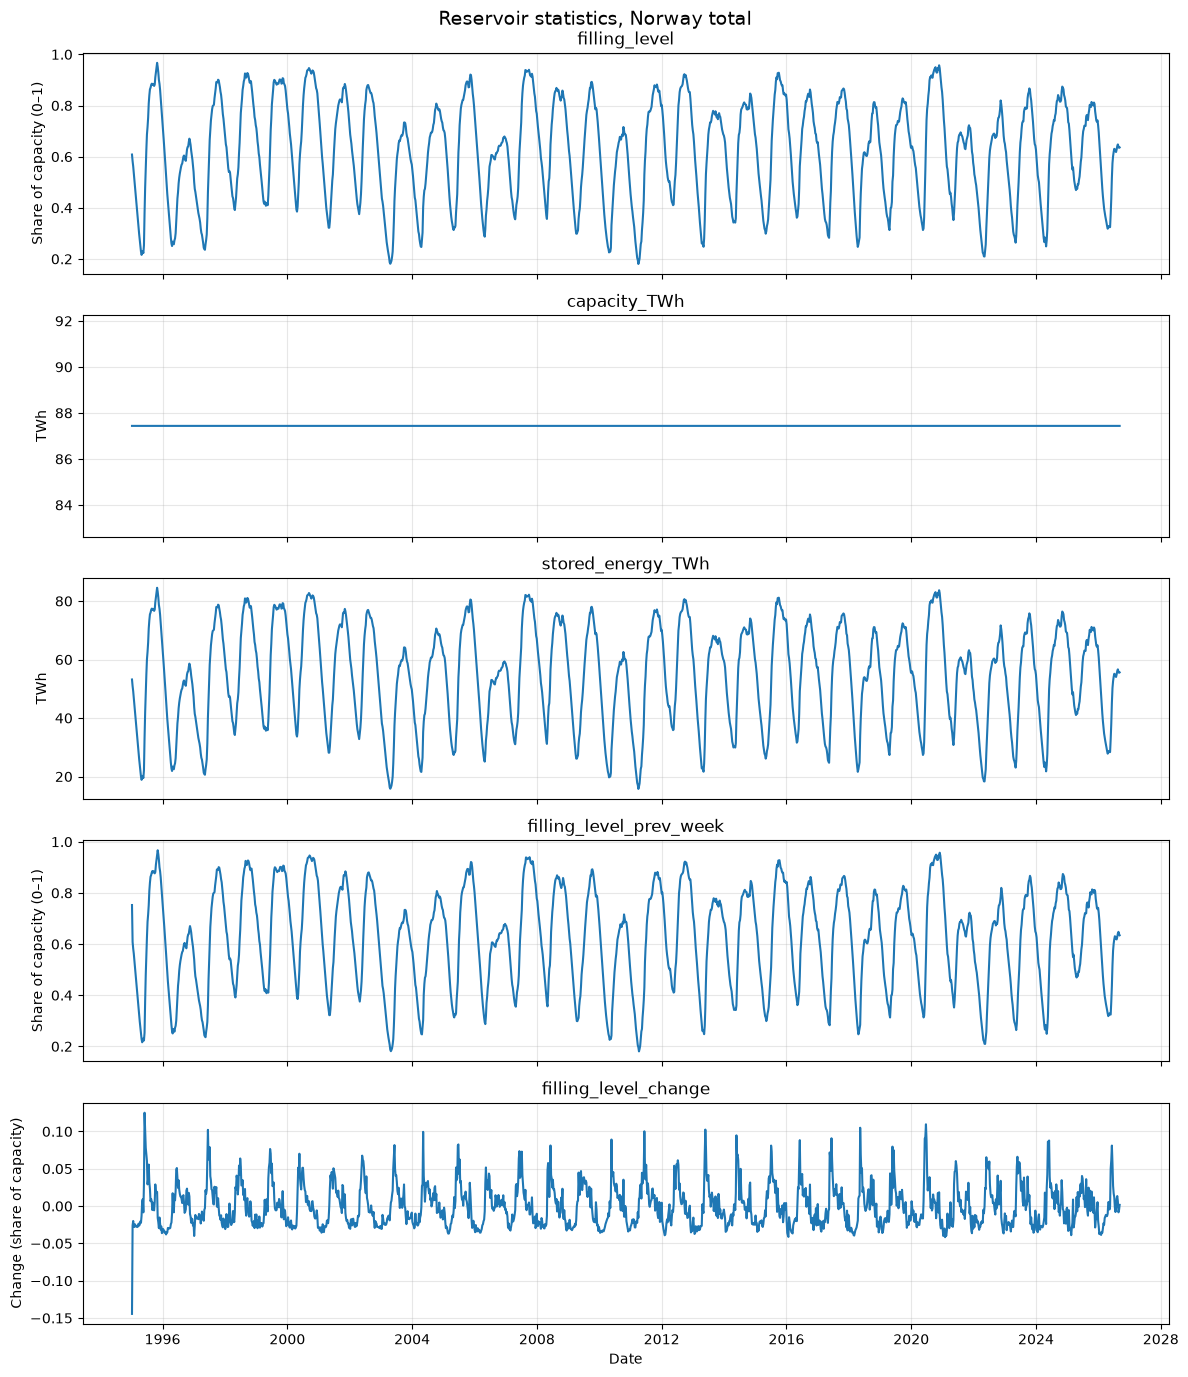

In [26]:
# Unit for each column, used as y-axis labels
units = {
    "filling_level": "Share of capacity (0–1)",
    "capacity_TWh": "TWh",
    "stored_energy_TWh": "TWh",
    "filling_level_prev_week": "Share of capacity (0–1)",
    "filling_level_change": "Change (share of capacity)",
}

# One subplot per column, sharing the time axis
fig, axes = plt.subplots(len(value_cols), 1, figsize=(12, 14), sharex=True)
for ax, col in zip(axes, value_cols):
    ax.plot(df.index, df[col])
    ax.set_title(col)
    ax.set_ylabel(units[col])
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Date")
fig.suptitle("Reservoir statistics, Norway total", fontsize=14)
plt.tight_layout()
plt.show()

## All of the columns plotted together

The columns have very different scales (0–1, around 87 TWh, and changes around 0). To compare them in one plot, each column is divided by its maximum absolute value, so every column lies between −1 and 1.

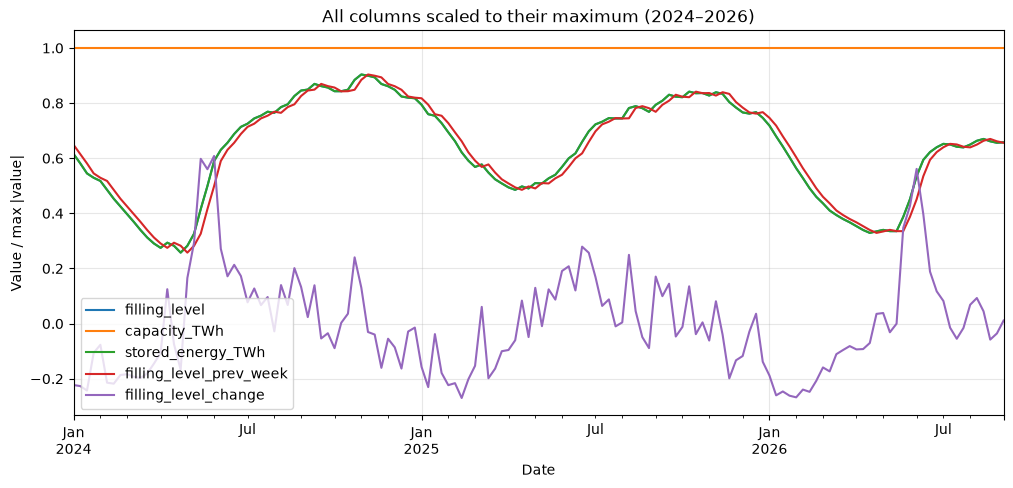

In [ ]:
# Scaling each column by its largest absolute value -> all values inside [-1, 1]
df_scaled = df / df.abs().max()

# Plotting only the last 3 years so the lines are more readable
df_scaled.loc["2024":].plot(figsize=(12, 5))
plt.title("All columns scaled to their maximum (2024–2026)")
plt.xlabel("Date")
plt.ylabel("Value / max |value|")
plt.grid(alpha=0.3)
plt.legend(loc="lower left")
plt.show()

## Log

...

## AI Usage

I am primally using Claude Opus 5 to help me with this project and also the built in chatbot in VScode. Claude is giving me guidance on how I should write my code and I usually double check with it to make sure that my work is correct and also if I need hints to get started with my next task in the project. I feel that it is more about understading the code and the choices that AI makes when coding it, rather than hard coding myself. Therefore I have a strict rule to always try and understand what I write from the chatbots before I go to the next task, and change some things so it becomes more like I would have done it myself. I also don't want cowork to just go into my file and do everything for me, because then I will become incredibly lazy and I want to acoid that. 